# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



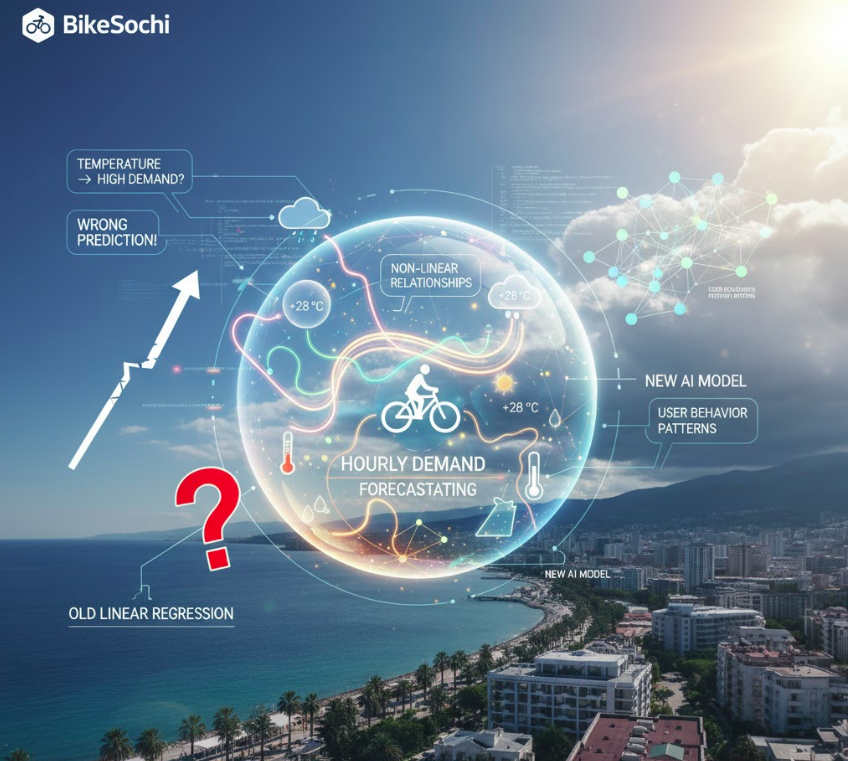

> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— baseline_linear_regression_pipeline.pkl — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть baseline_linear_regression_pipeline.pkl и train_data.csv и test_data.csv.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите .pkl файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



# **Авторское решение**

<h3>Цель:</h3>
<p>Разработать модель машинного обучения для более точного прогнозирования почасового спроса на велосипеды, способную учитывать нелинейные зависимости между погодными условиями и активностью</p>

<h3>Задача:</h3>
<p>Сравнить качество базовой модели линейной регрессии с нелинейными моделями (KNN и Decision Tree), подобрать гиперпараметры с помощью Optuna, выбрать лучшую модель и сохранить готовый пайплайн для дальнейшего использования.</p>

<h3>План работы</h3>
<ul>
    <li>Этап 1. Подготовка среды: загрузка библиотек, фиксация <code>random_state</code>, загрузка обучающего и тестового датасетов</li>
    <li>Этап 2. Анализ данных (EDA): изучение структуры данных, типов признаков, проверка пропусков и дубликатов, анализ распределения целевой переменной</li>
    <li>Этап 3 Предобработка: Cобираем пайплайн заполняем пропуски отделяем целевую переменную</li>
    <li>Этап 4. Обучение моделей: построение пайплайнов для KNN и Decision Tree</li>
    <li>Этап 5. Подбор гиперпараметров: оптимизация параметров моделей с помощью библиотеки Optuna</li>
    <li>Этап 6. Сравнение моделей: анализ метрик качества, сравнение результатов baseline и новых моделей, выбор лучшей модели.</li>
    <li>Этап 7. Финальная модель: обучение лучшей модели, сохранение готового пайплайна с помощью <code>joblib</code>.</li>
    <li>Этап 8. Отчёт: описание полученных результатов, сравнение моделей и обоснование выбора лучшего решения.</li>
</ul>

<h2>Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек.</h2>
<ul>
    <li>Установим и настроим библиотеки</li>
    <li>Зафиксируем <code>random_state</code> и параметры отображения</li>
    <li>Загрузим данные из CSV-файлов</li>
</ul>

<h3>Установим и настроим библиотеки</h3>

In [249]:
!pip install phik
!pip install optuna

import numpy as np
import pandas as pd
import phik
import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold, cross_val_predict, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


<h3>Зафиксируем <code>random_state</code> и параметры отображения</h3>

In [250]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

<ul>
    <li><code>plt.style.use('default')</code> - использование стандартного стиля визуализации matplotlib.</li>
    <li><code>plt.rcParams['figure.figsize'] = (10, 6)</code> - размер графиков.</li>
    <li><code>plt.rcParams['font.size'] = 12</code> - размер шрифта на графиках.</li>
    <li><code>RANDOM_STATE = 42</code> - фиксация генератора случайных чисел для воспроизводимости результатов.</li>
</ul>

<h3>Загрузим данные из CSV-файлов:</h3>
<ul>
    <li>ds_s14_train_data.csv</li>
    <li>ds_s14_test_data.csv</li>
</ul>

In [251]:
try:
    train = pd.read_csv('ds_s14_train_data.csv')
    test = pd.read_csv('ds_s14_test_data.csv')

except:
    train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')
    test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')

<h4>Проверка выгруженных данных</h4>

In [252]:
datasets = {
    'train': train,
    'test': test
}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')

train: (7008, 16)
test: (1752, 16)


данные выгружены корректно, можно переходить к EDA

<h2> Этап 2 Анализ данных (EDA): изучаем признаки, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками. </h2>

<h3>Первичный анализ выгруженных данных</h3>

In [253]:
def datasets_info(datasets):
    for name, df in datasets.items():
        print(name)
        
        for col in df.columns:
            print(f"\t{col}"
                  f"\n\t\tтип: {df[col].dtype}"
                  f"\n\t\tвсего строк: {len(df[col])}"
                  f"\n\t\tпропусков: {df[col].isna().sum()}"
                  f"\n\t\tпримеры возможных значений: {list(df[col].dropna().unique()[:5])}")
        print()
datasets_info(datasets)

train
	Temperature
		тип: float64
		всего строк: 7008
		пропусков: 0
		примеры возможных значений: [np.float64(20.3), np.float64(25.4), np.float64(-6.9), np.float64(-5.2), np.float64(23.4)]
	Humidity(%)
		тип: float64
		всего строк: 7008
		пропусков: 250
		примеры возможных значений: [np.float64(35.0), np.float64(55.0), np.float64(39.0), np.float64(37.0), np.float64(34.0)]
	Wind speed (m/s)
		тип: float64
		всего строк: 7008
		пропусков: 210
		примеры возможных значений: [np.float64(2.4), np.float64(3.2), np.float64(1.6), np.float64(2.2), np.float64(2.1)]
	Visibility (10m)
		тип: float64
		всего строк: 7008
		пропусков: 259
		примеры возможных значений: [np.float64(2000.0), np.float64(1308.0), np.float64(1911.0), np.float64(1553.0), np.float64(118.0)]
	Dew point temperature
		тип: float64
		всего строк: 7008
		пропусков: 0
		примеры возможных значений: [np.float64(4.3), np.float64(15.6), np.float64(-18.5), np.float64(-17.6), np.float64(6.6)]
	Solar Radiation (MJ/m2)
		тип: float64
		вс

<h4>Вывод</h4>

<p>
Обучающая и тестовая выборки имеют одинаковый набор признаков. Основная часть признаков описывает погодные условия, также представлены календарные признаки и признаки времени суток.
</p>

<p>
В данных присутствуют пропуски в числовых признаках. Бинарные признаки <code>Holiday</code> и <code>Functioning Day</code> имеют категориальный тип; для более эффективного хранения их можно было бы представить в виде булевых значений. Признаки <code>Time_Period_*</code> являются результатом предварительного One-Hot Encoding. Для более гибкой и воспроизводимой предобработки предпочтительнее хранить исходный категориальный признак и выполнять кодирование внутри <code>Pipeline</code>.
</p>

<h3>Распределение целевой переменной</h3>

count    7008.000000
mean      705.606022
std       646.311790
min         0.000000
25%       190.750000
50%       504.500000
75%      1070.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64
Выбросы:
Количество: 121
Процент: 1.73
Границы: -1128.12 2388.88
Первые 5 выбросов выше верхней границы: [2392 2397 2398 2400 2401]
5 максимальных значений: [3365 3384 3404 3418 3556]


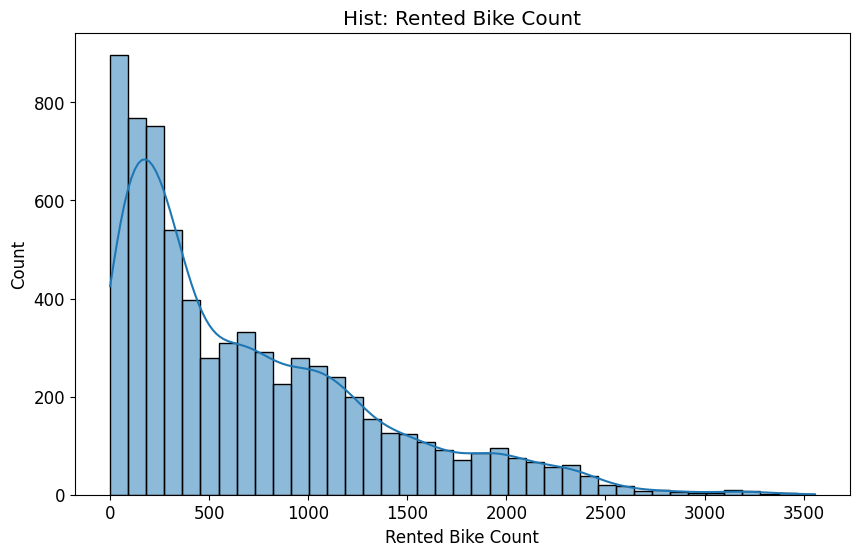

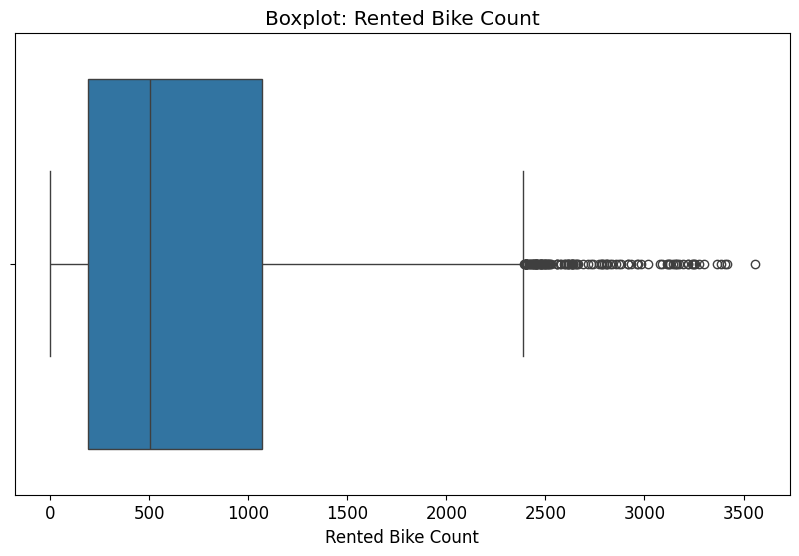

count    1752.000000
mean      700.586187
std       639.880816
min         0.000000
25%       194.750000
50%       503.500000
75%      1042.000000
max      3380.000000
Name: Rented Bike Count, dtype: float64
Выбросы:
Количество: 39
Процент: 2.23
Границы: -1076.12 2312.88
Первые 5 выбросов выше верхней границы: [2322 2326 2330 2337 2348]
5 максимальных значений: [3069 3154 3227 3309 3380]


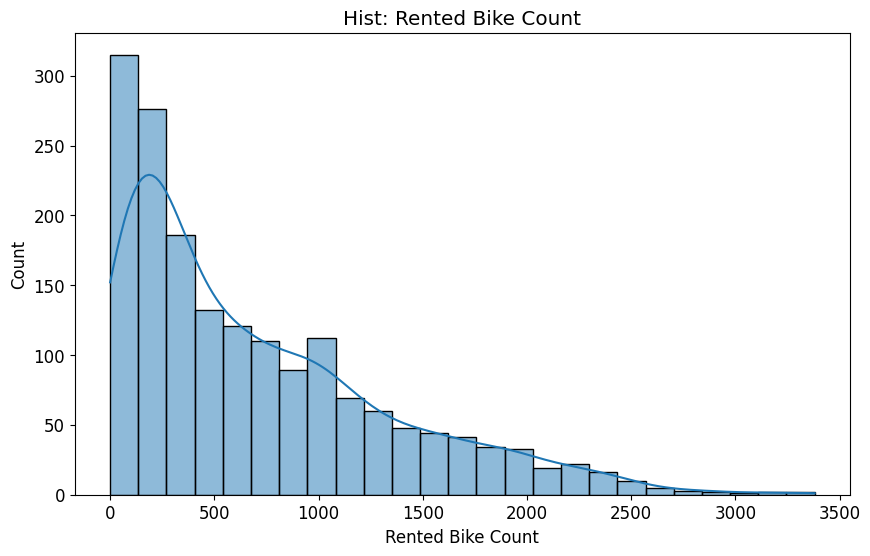

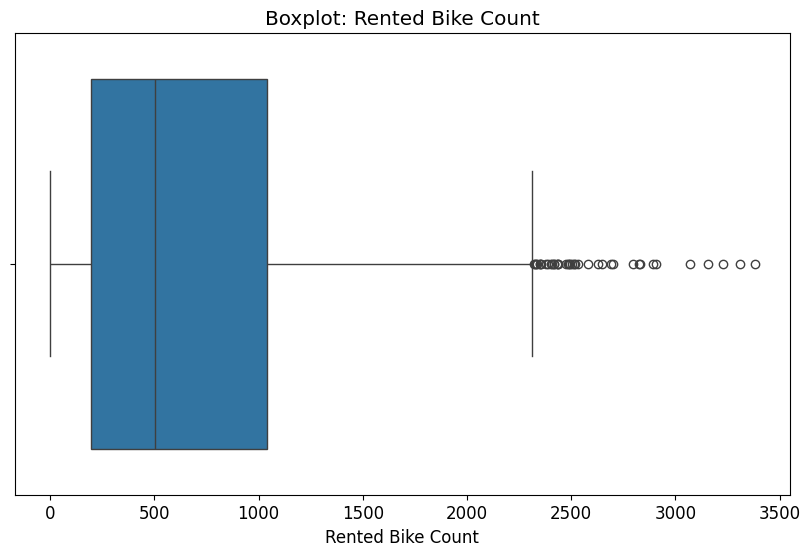

In [254]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers) / len(data) * 100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы:", high_outliers.head(5).values)
    print("5 максимальных значений:", high_outliers.tail(5).values)
    
    sns.histplot(data, kde=True)
    plt.title(f"Hist: {col}")
    plt.show()

    sns.boxplot(x=data)
    plt.title(f"Boxplot: {col}")
    plt.show()
data_review(train, 'Rented Bike Count')
data_review(test, 'Rented Bike Count')

<h4>Вывод</h4>

<p>
Распределение целевой переменной в обучающей и тестовой выборках совпадает. Среднее значение, медиана, q характеристики и стандартное отклонение отличаются незначительно
</p>

<p>
В обеих выборках присутствует небольшое количество выбросов, при этом максимальные значения не сильно разлечаются. Существенных разницы в распределении целевой переменной нет
</p>

In [255]:
def missing_report(df):
    total = len(df)
    for col in df.columns:
        print(col)
        print("\t", "пропусков:", df[col].isna().sum())
        print("\t", f"доля: {round(df[col].isna().sum() / total * 100, 2)}%")
    df_clean = df.dropna()
    print("Без удаления пропусков строк:", len(df))
    print("После удаления:", len(df_clean))
    print("Потеря:", len(df) - len(df_clean))
    print("Доля потерь:", (len(df) - len(df_clean)) / len(df))

print("Обучающая выборка")
missing_report(train)
print("\nТестовая выборка")
missing_report(test)

Обучающая выборка
Temperature
	 пропусков: 0
	 доля: 0.0%
Humidity(%)
	 пропусков: 250
	 доля: 3.57%
Wind speed (m/s)
	 пропусков: 210
	 доля: 3.0%
Visibility (10m)
	 пропусков: 259
	 доля: 3.7%
Dew point temperature
	 пропусков: 0
	 доля: 0.0%
Solar Radiation (MJ/m2)
	 пропусков: 210
	 доля: 3.0%
Rainfall(mm)
	 пропусков: 262
	 доля: 3.74%
Snowfall (cm)
	 пропусков: 263
	 доля: 3.75%
Seasons
	 пропусков: 0
	 доля: 0.0%
Holiday
	 пропусков: 0
	 доля: 0.0%
Functioning Day
	 пропусков: 0
	 доля: 0.0%
Time_Period_Evening
	 пропусков: 0
	 доля: 0.0%
Time_Period_Late Evening
	 пропусков: 0
	 доля: 0.0%
Time_Period_Morning
	 пропусков: 0
	 доля: 0.0%
Time_Period_Night
	 пропусков: 0
	 доля: 0.0%
Rented Bike Count
	 пропусков: 0
	 доля: 0.0%
Без удаления пропусков строк: 7008
После удаления: 5674
Потеря: 1334
Доля потерь: 0.1903538812785388

Тестовая выборка
Temperature
	 пропусков: 0
	 доля: 0.0%
Humidity(%)
	 пропусков: 72
	 доля: 4.11%
Wind speed (m/s)
	 пропусков: 52
	 доля: 2.97%
Visibil

<h4>Вывод:</h4>
<p>
Удаление строк с пропусками приводит к значительной потере данных (19%), поэтому не имеет смысла. Пропуски равномерно распределены в обоих датасетах.  
Оптимально использовать <code>SimpleImputer</code> для заполнения пропусков.
</p>

<h3>Обработка дубликатов</h3>

In [256]:
def duplicates_report(df, id_col=None):
    full_dup = df.duplicated().sum()
    print("Полные дубликаты строк:", full_dup)
    
    if id_col is not None and id_col in df.columns:
        id_dup = df.duplicated(subset=[id_col]).sum()
        print("Дубликаты по id:", id_dup)
        no_id = df.drop(columns=[id_col])
        no_id_dup = no_id.duplicated().sum()
        print("Дубликаты без id:", no_id_dup)
        
print("Обучающая выборка")
duplicates_report(train)
print("\nТестовая выборка")
duplicates_report(test)

Обучающая выборка
Полные дубликаты строк: 0

Тестовая выборка
Полные дубликаты строк: 0


дубликатов не обнаружено

<h3>Анализ выбросов и распределления</h3>

Temperature
count    1752.000000
mean       13.162957
std        12.024380
min       -17.800000
25%         3.900000
50%        14.450000
75%        22.900000
max        37.900000
Name: Temperature, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -24.6 51.4
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


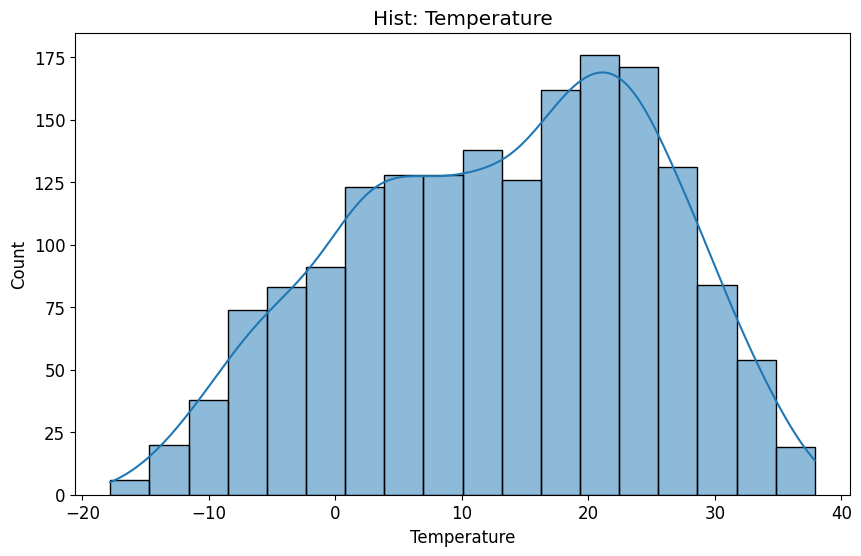

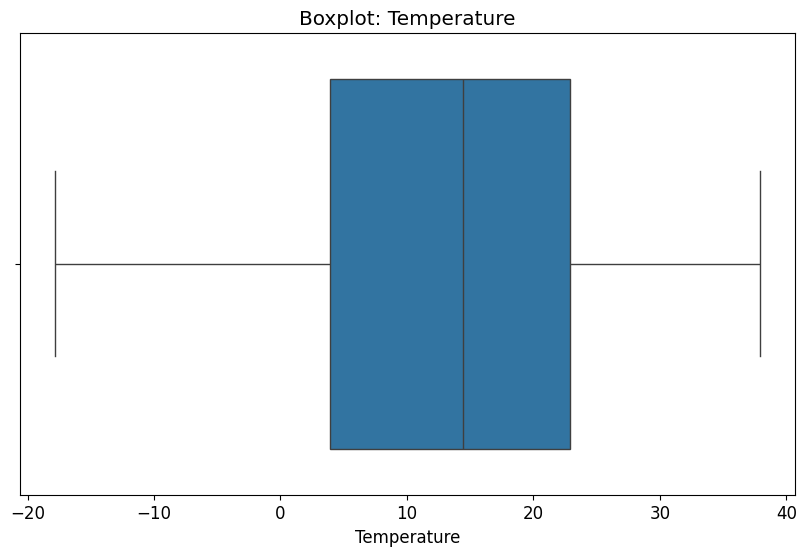

Humidity(%)
count    1680.000000
mean       58.172619
std        20.602653
min         0.000000
25%        42.000000
50%        57.000000
75%        74.000000
max        98.000000
Name: Humidity(%), dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -6.0 122.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


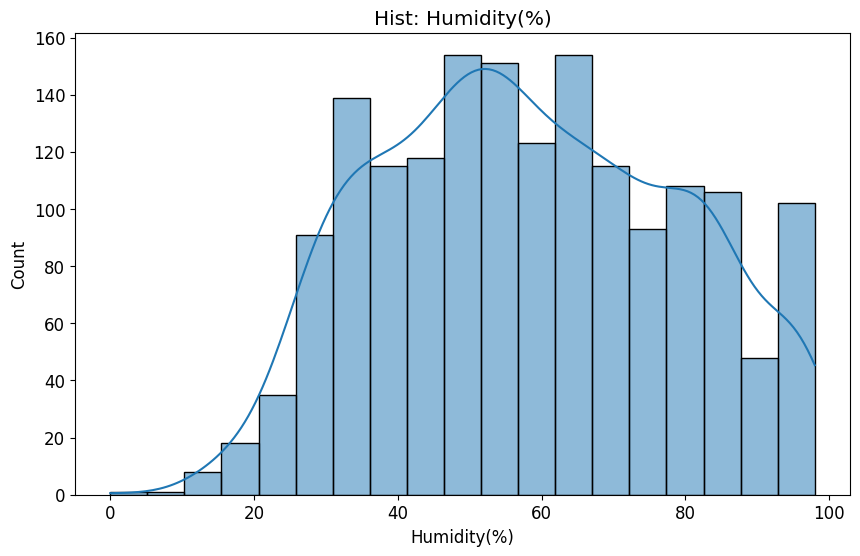

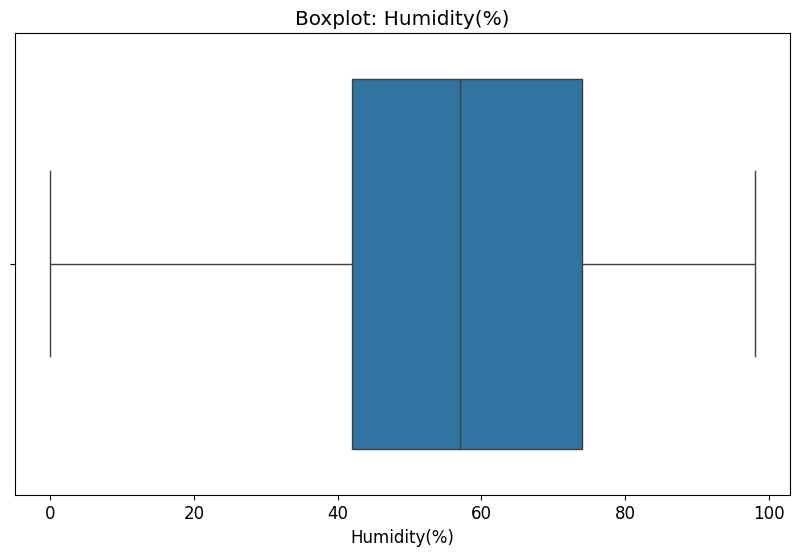

Wind speed (m/s)
count    1700.000000
mean        1.737000
std         1.013244
min         0.000000
25%         1.000000
50%         1.600000
75%         2.300000
max         5.600000
Name: Wind speed (m/s), dtype: float64
Выбросы:
Количество: 36
Процент: 2.12
Границы: -0.95 4.25
Первые 5 выбросов выше верхней границы: [4.3 4.3 4.3 4.3 4.3]
5 максимальных значений: [5.3 5.3 5.4 5.4 5.6]


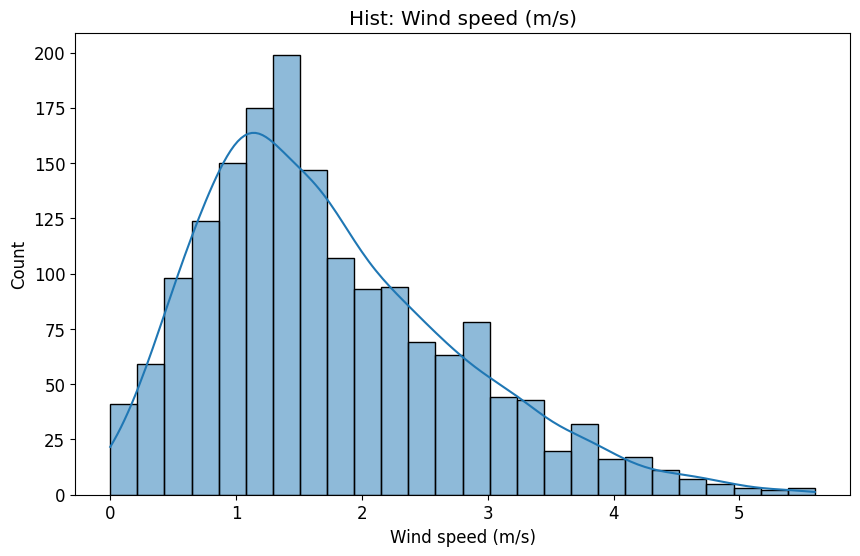

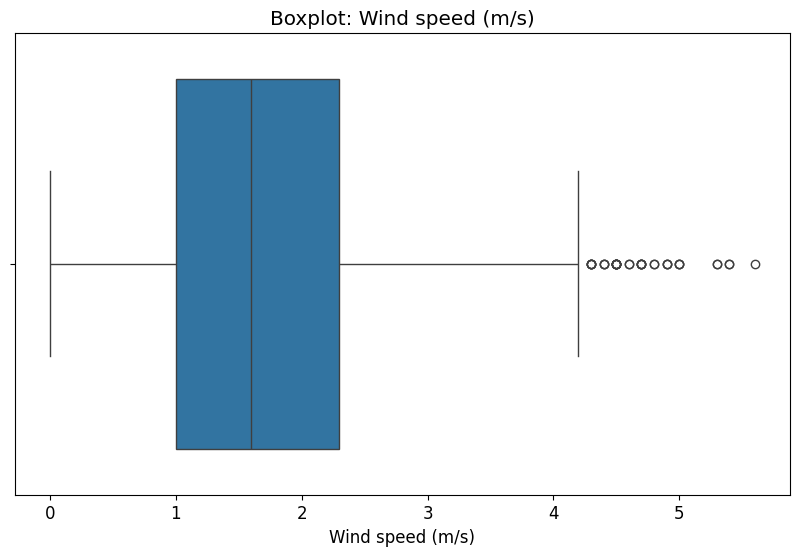

Visibility (10m)
count    1680.000000
mean     1442.061905
std       613.892076
min        34.000000
25%       942.750000
50%      1723.500000
75%      2000.000000
max      2000.000000
Name: Visibility (10m), dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -643.12 3585.88
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


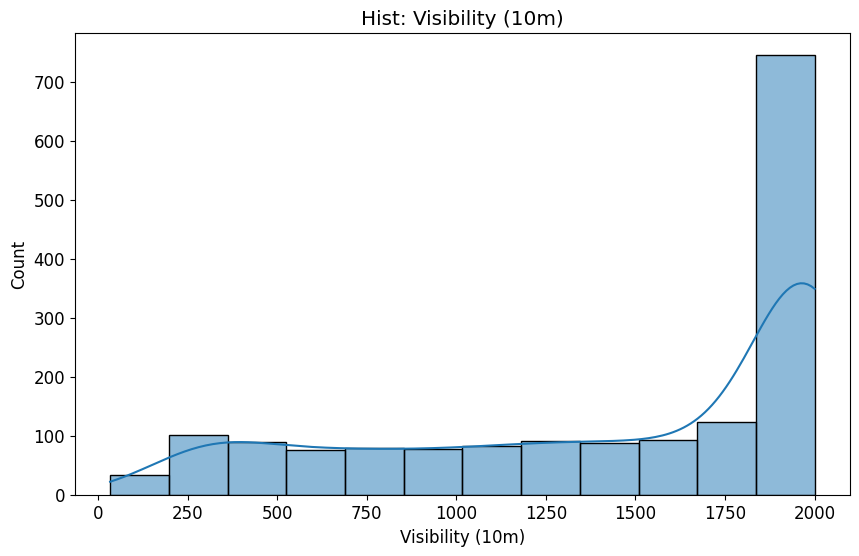

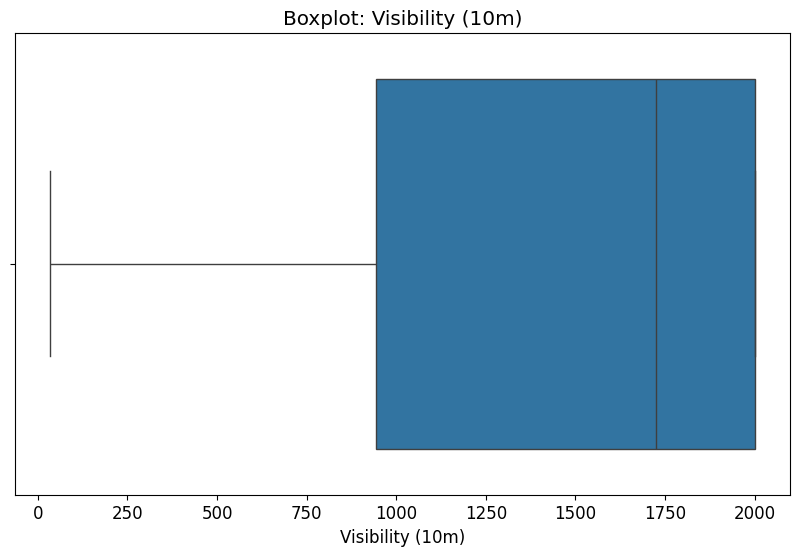

Dew point temperature
count    1752.000000
mean        4.283105
std        13.169451
min       -29.200000
25%        -4.500000
50%         5.800000
75%        15.100000
max        27.200000
Name: Dew point temperature, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -33.9 44.5
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []


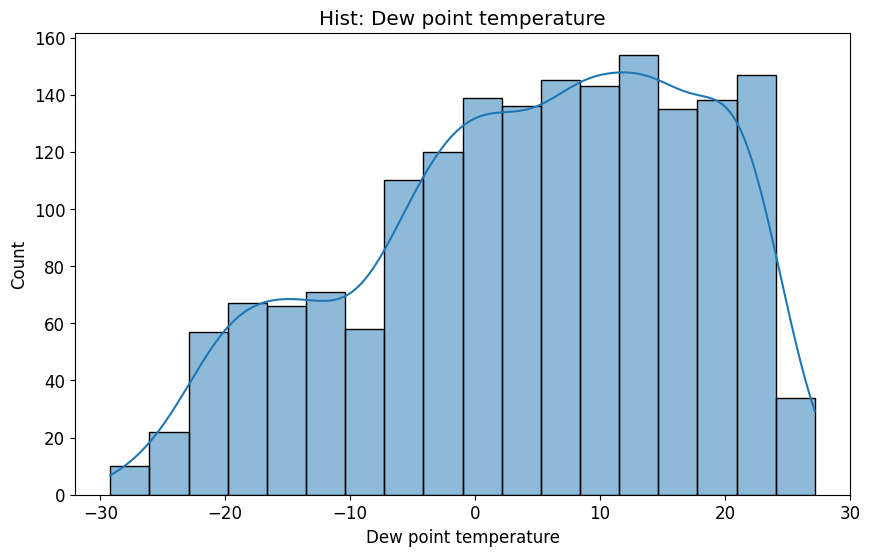

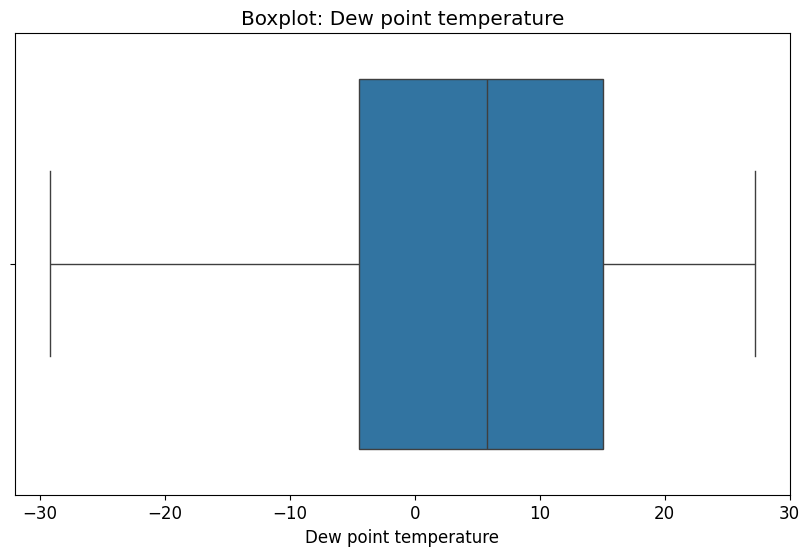

Solar Radiation (MJ/m2)
count    1700.000000
mean        0.578035
std         0.887957
min         0.000000
25%         0.000000
50%         0.020000
75%         0.910000
max         3.420000
Name: Solar Radiation (MJ/m2), dtype: float64
Выбросы:
Количество: 147
Процент: 8.65
Границы: -1.36 2.28
Первые 5 выбросов выше верхней границы: [2.28 2.29 2.31 2.31 2.32]
5 максимальных значений: [3.33 3.34 3.41 3.42 3.42]


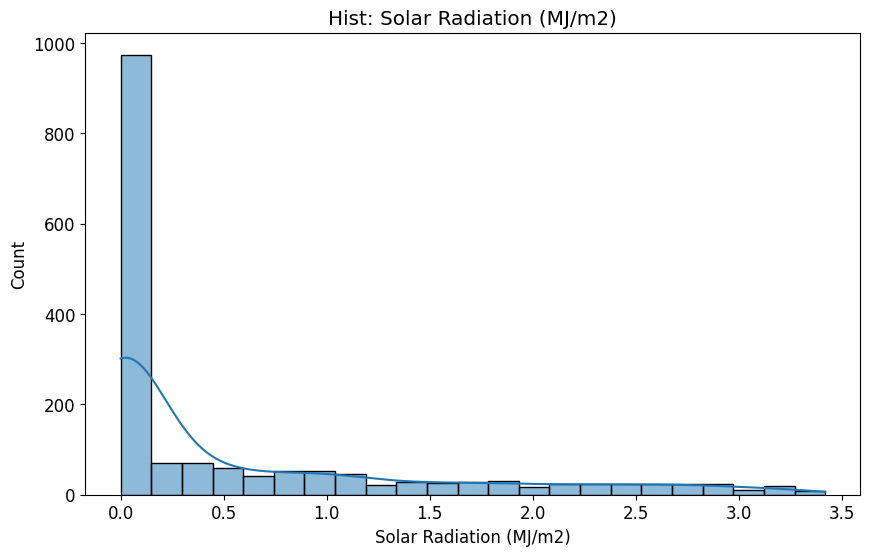

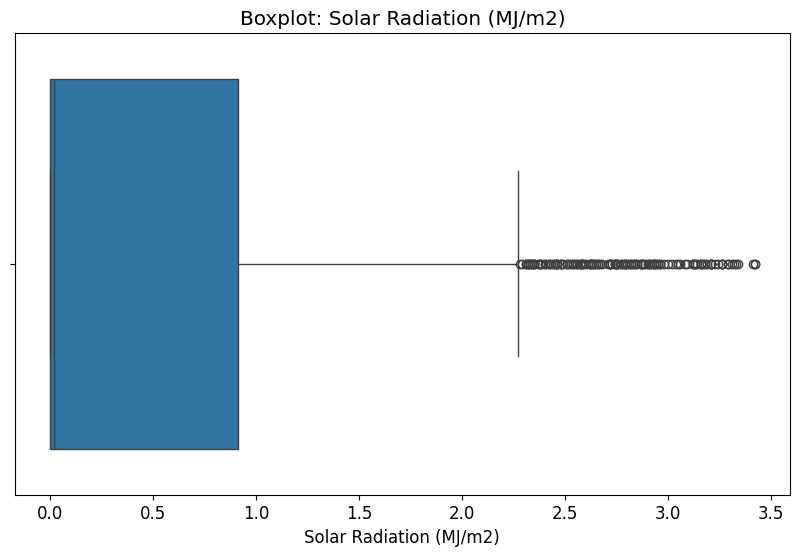

Rainfall(mm)
count    1688.000000
mean        0.145794
std         0.920346
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        15.500000
Name: Rainfall(mm), dtype: float64
Выбросы:
Количество: 120
Процент: 7.11
Границы: 0.0 0.0
Первые 5 выбросов выше верхней границы: [0.1 0.1 0.1 0.1 0.1]
5 максимальных значений: [ 9.5 12.  12.5 13.5 15.5]


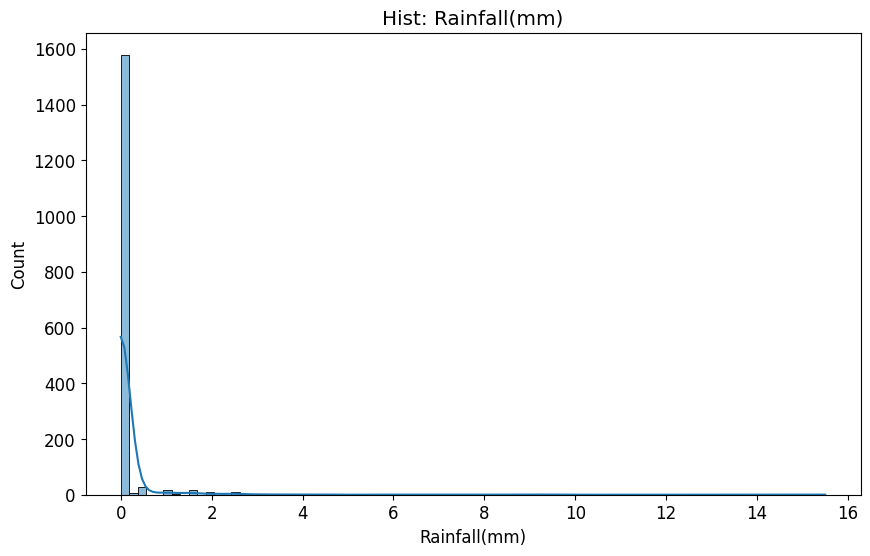

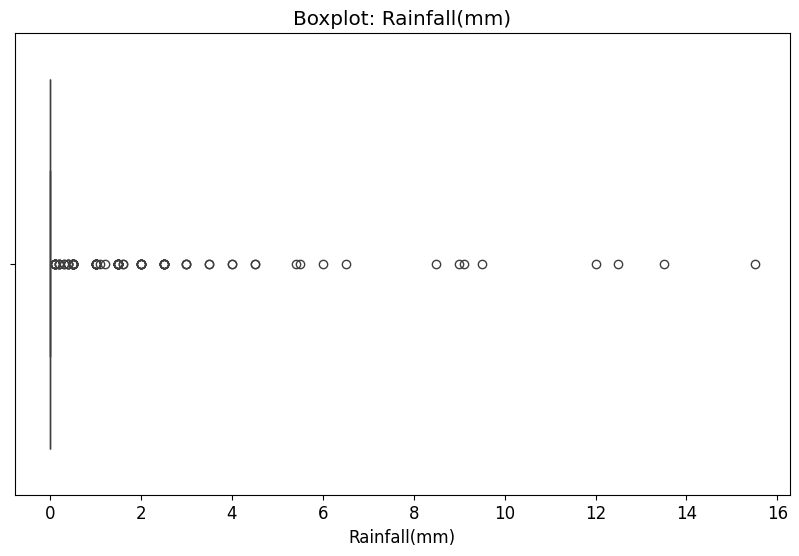

Snowfall (cm)
count    1691.000000
mean        0.078001
std         0.438827
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         7.100000
Name: Snowfall (cm), dtype: float64
Выбросы:
Количество: 87
Процент: 5.14
Границы: 0.0 0.0
Первые 5 выбросов выше верхней границы: [0.2 0.2 0.2 0.3 0.3]
5 максимальных значений: [4.3 4.3 4.8 4.8 7.1]


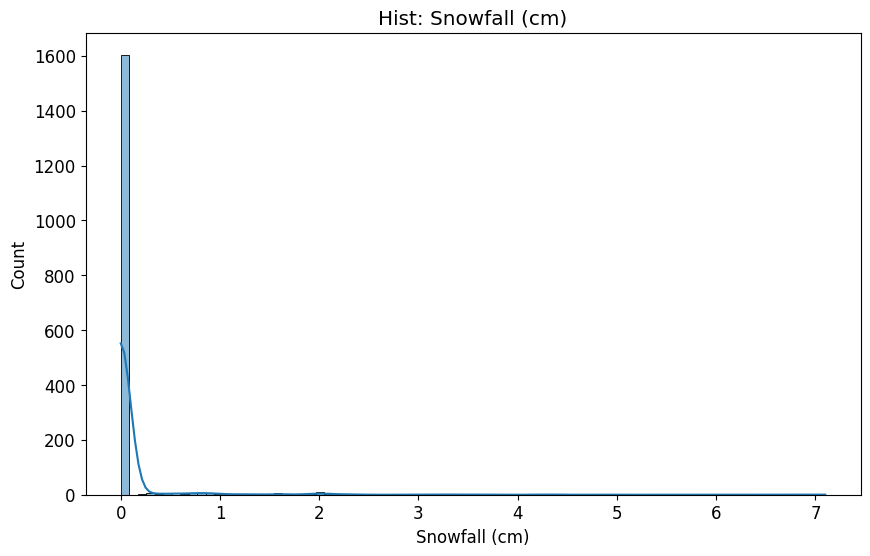

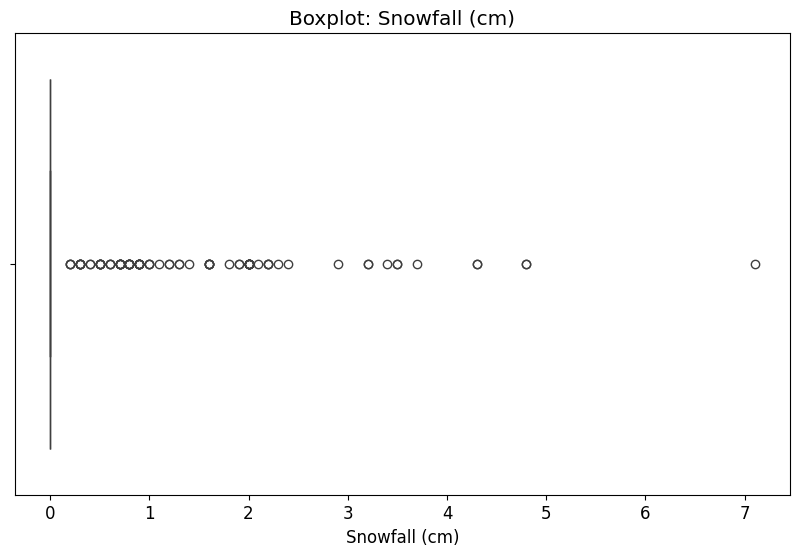

In [257]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = num_cols.drop("Rented Bike Count", errors="ignore")

for col in num_cols:
    print(col)
    data_review(df, col)

<h3>Вывод по выбросам</h3>

<p>В числовых признаках преобладает неравномерное распределение </p>

<ul>
  <li><b>Temperature, Humidity, Visibility, Dew point temperature</b>  выбросы не выявлены по IQR</li>
  <li><b>Wind speed</b> небольшое количество выбросов, обычные экстремальные значения для погоды</li>
  <li><b>Solar Radiation</b> много выбросов, распределение с сильной правой асимметрией</li>
  <li><b>Rainfall</b> 7% выбросов, большинство значений нулевые, есть редкие сильные осадки.</li>
  <li><b>Snowfall</b> 5% выбросов, анналогично <b>Rainfall</b></li>
</ul>

<p>
Вывод: большинство признаков устойчивы, но <b>Solar Radiation, Rainfall и Snowfall</b> имеют выбросы и сильную асимметрию распределения. Это нормально для погодных данных, и не требуют удаления
</p>

<h3>Корреляции</h3>

In [258]:
def phik_corr_matrix(df, interval_cols=None, drop_cols=None):
    data = df.copy()
    
    if drop_cols:
        data = data.drop(columns=drop_cols, errors='ignore')
    
    corr = data.phik_matrix(interval_cols=interval_cols)
    print(corr)
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap='coolwarm', annot=True)
    plt.show()
    
    return corr

                          Temperature  Humidity(%)  Wind speed (m/s)  \
Temperature                  1.000000     0.413596          0.241127   
Humidity(%)                  0.413596     1.000000          0.372896   
Wind speed (m/s)             0.241127     0.372896          1.000000   
Visibility (10m)             0.365133     0.587097          0.186827   
Dew point temperature        0.892561     0.570817          0.273703   
Solar Radiation (MJ/m2)      0.401338     0.490686          0.370425   
Rainfall(mm)                 0.040790     0.253131          0.000000   
Snowfall (cm)                0.273464     0.151849          0.100297   
Seasons                      0.814083     0.306847          0.186434   
Holiday                      0.186881     0.116650          0.072756   
Functioning Day              0.255160     0.081928          0.000000   
Time_Period_Evening          0.167372     0.274000          0.339686   
Time_Period_Late Evening     0.064350     0.154658          0.08

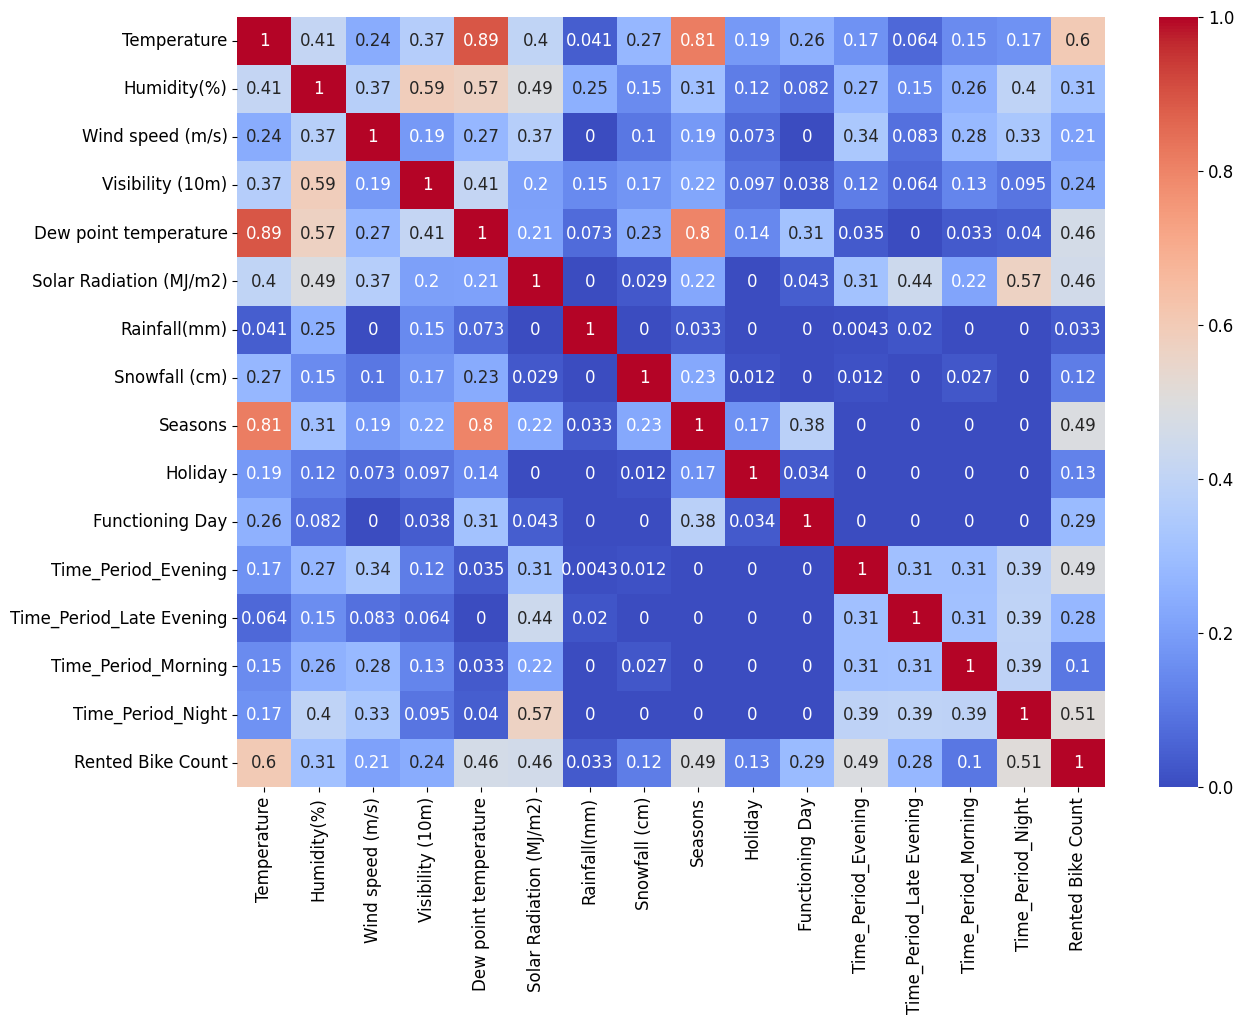

                          Temperature  Humidity(%)  Wind speed (m/s)  \
Temperature                  1.000000     0.409666          0.281086   
Humidity(%)                  0.409666     1.000000          0.385789   
Wind speed (m/s)             0.281086     0.385789          1.000000   
Visibility (10m)             0.364577     0.588319          0.209117   
Dew point temperature        0.891337     0.552092          0.297161   
Solar Radiation (MJ/m2)      0.383870     0.484227          0.406611   
Rainfall(mm)                 0.000000     0.422194          0.000000   
Snowfall (cm)                0.252292     0.080181          0.000000   
Seasons                      0.814764     0.285523          0.172414   
Holiday                      0.201422     0.133536          0.000000   
Functioning Day              0.247155     0.049083          0.000000   
Time_Period_Evening          0.156739     0.296362          0.380950   
Time_Period_Late Evening     0.106651     0.147747          0.00

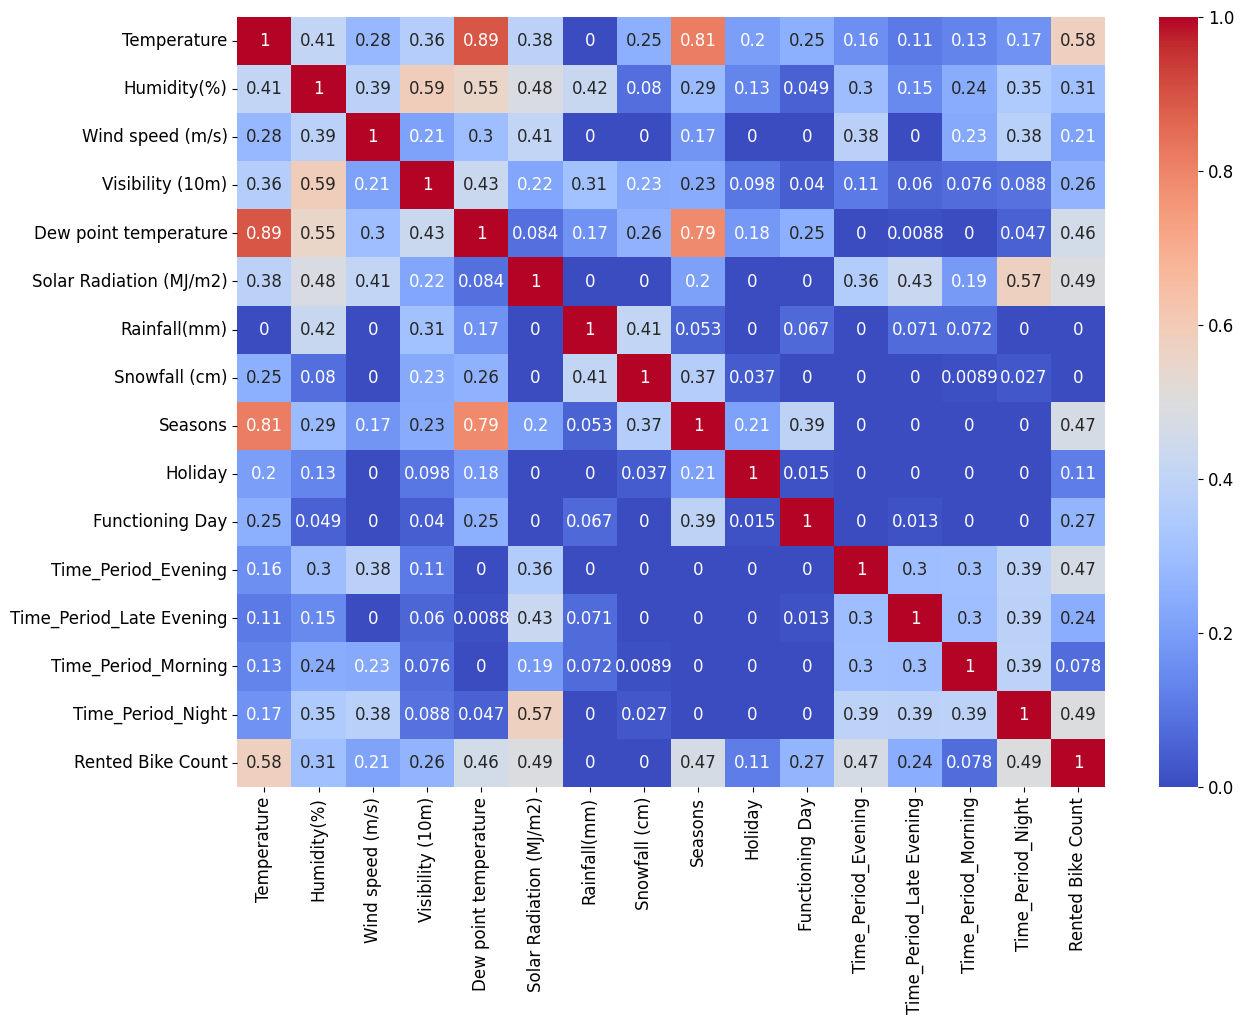

In [259]:
interval_cols = ["Temperature", "Humidity(%)", "Wind speed (m/s)", "Visibility (10m)",
                 "Dew point temperature", "Solar Radiation (MJ/m2)", "Rainfall(mm)", "Snowfall (cm)", "Rented Bike Count"]
corr_train = phik_corr_matrix(train, interval_cols=interval_cols)
corr_test = phik_corr_matrix(test, interval_cols=interval_cols, drop_cols=None)

<h3>Построим графики для выявления зависимости спроса от различных погодных характеристик</h3>

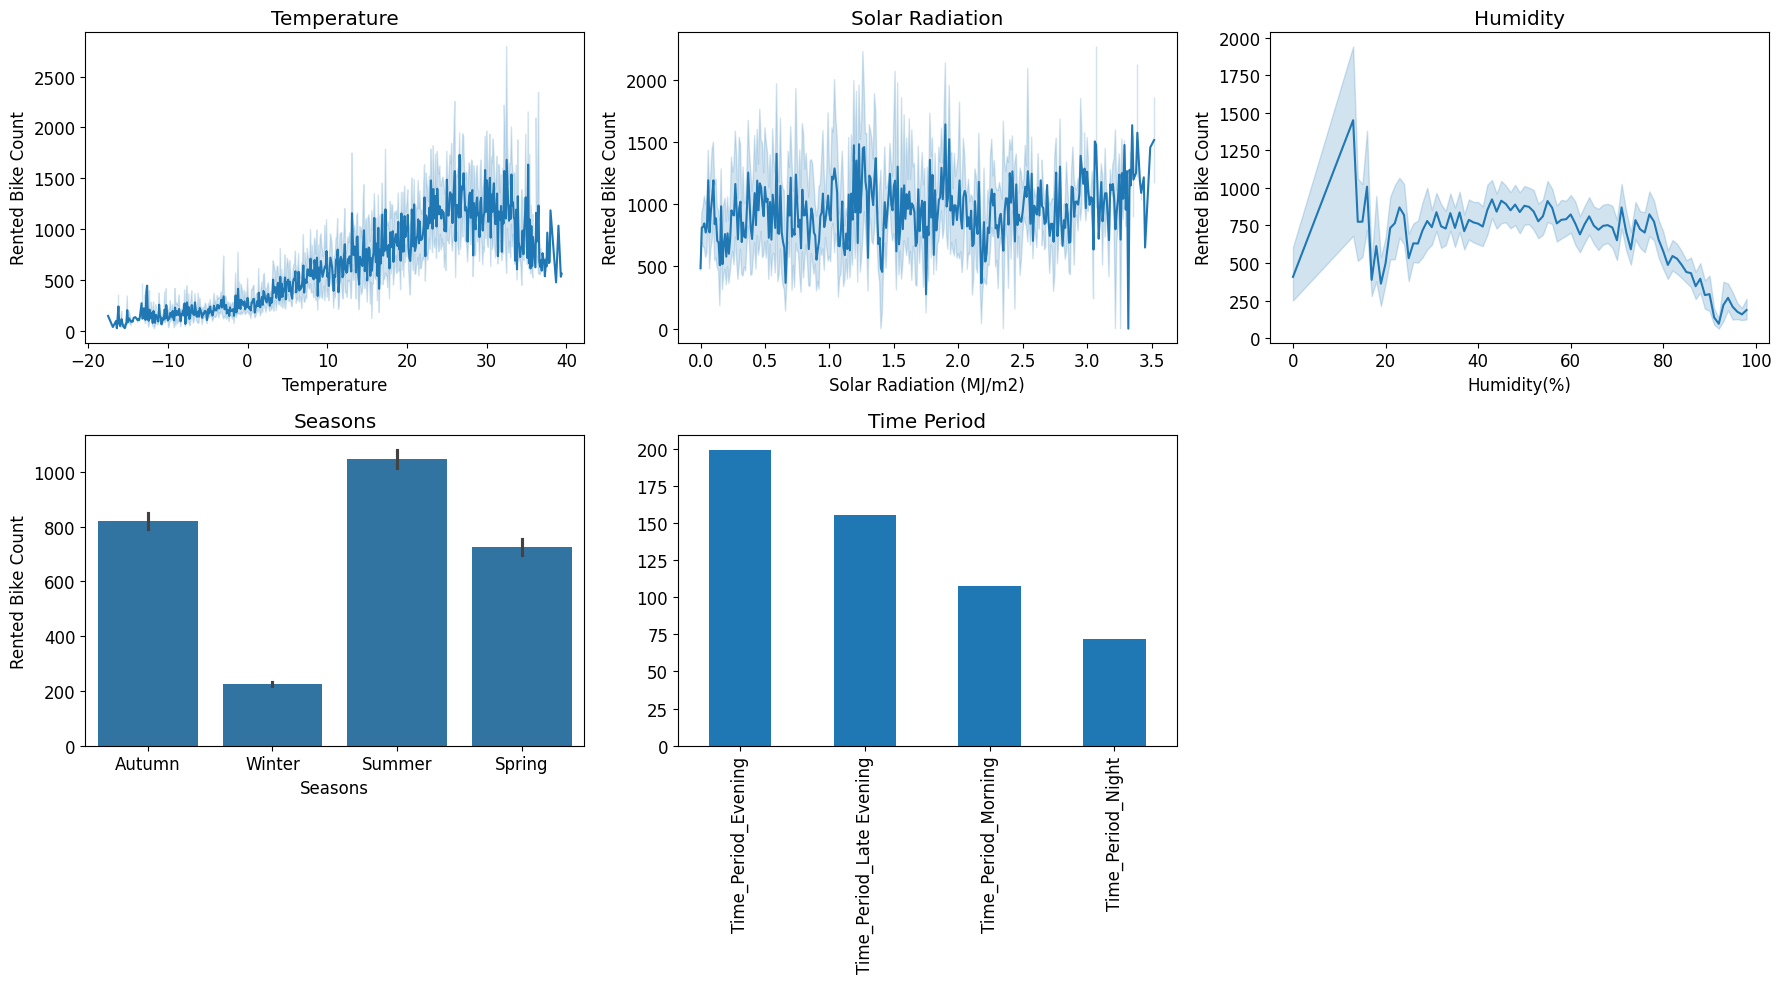

In [260]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

sns.lineplot(data=train, x='Temperature',y='Rented Bike Count', ax=axes[0])
axes[0].set_title('Temperature')

sns.lineplot(data=train, x='Solar Radiation (MJ/m2)', y='Rented Bike Count', ax=axes[1])
axes[1].set_title('Solar Radiation')

sns.lineplot(data=train, x='Humidity(%)', y='Rented Bike Count', ax=axes[2])
axes[2].set_title('Humidity')

sns.barplot(data=train, x='Seasons', y='Rented Bike Count', ax=axes[3])
axes[3].set_title('Seasons')

time_cols = [c for c in train.columns if 'Time_Period' in c]
train[time_cols].mul(train['Rented Bike Count'], axis=0).mean().plot(kind='bar', ax=axes[4])
axes[4].set_title('Time Period')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

<h4>Вывод</h4>
Наибольшее влияние на спрос оказывает температура воздуха. Графики показывают нелинейный характер: при отрицательных температурах количество аренд минимально, потом спрос растет и достигает максимума при температуре 25–30 . При дальнейшем повышении температуры идет снижение числа поездок


Солнечная радиация так же оказывает влияние на количество аренд. При увеличении солнечной радиации спрос возрастает, однако зависимость слабее, чем для температуры, поскольку разброс значений большой


Влажность воздуха отрицаткльно влияет на целевую переменную. Наиболее благоприятными являются значения 40–70 %. При высокой влажности спрос снижается. Возможно, влажность выступает индикатором дождливой и пасмурной погоды, при которой использование велосипедов падает


Сезонность также влияет на спрос. Максимальное количество аренд приходится на лето, меньше на осень и весну,зимой минимальная активность


Различия спроса в зависимости от времени суток: наибольший спрос в вечерние часы, ниже поздним вечером. Утром количество ещё меньше, а ночью спрос достигает минимальных значений.


Зависимость целевой переменной от факторов окружающей среды имеет нелинейный характер. Это объясняет, почему линейные модели могут недостаточно точно прогнозировать количество аренд велосипедов. Также , влияние осадков отражается через влажность воздуха: в дождливую погоду влажность резко возрастает, поэтому именно она становится более информативным признаком для модели, чем сам факт наличия осадков


<h2>Этап 3 Предобработка: Cобираем пайплайн заполняем пропуски отделяем целевую переменную</h2>

<h3>Выделим целевую переменную</h3>

In [261]:
X_train = train.drop(columns='Rented Bike Count')
y_train = train['Rented Bike Count']

X_test = test.drop(columns='Rented Bike Count')
y_test = test['Rented Bike Count']

<h3>Заполнение пропусков</h3>

Заполним пропуски до трансформера, так как для числовых признаков лучше считать медиану для заполнения по сезону

In [262]:
def fill_by_group_median(df, group_col, num_cols, medians=None):
    df = df.copy()    
    if medians is None:
        medians = df.groupby(group_col)[num_cols].median()
    
    global_medians = medians.median()
    
    for col in num_cols:
        fill_values = df[group_col].map(medians[col])
        fill_values = fill_values.fillna(global_medians[col])
        df[col] = df[col].fillna(fill_values)
    
    return df, medians

num_cols = ['Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
            'Dew point temperature', 'Solar Radiation (MJ/m2)', 
            'Rainfall(mm)', 'Snowfall (cm)']

X_train, season_medians = fill_by_group_median(X_train, group_col='Seasons',  num_cols=num_cols)

X_test, skip = fill_by_group_median(X_test, group_col='Seasons', num_cols=num_cols, medians=season_medians)

In [263]:
missing_report(X_train)
print('='*50)
missing_report(X_test)

Temperature
	 пропусков: 0
	 доля: 0.0%
Humidity(%)
	 пропусков: 0
	 доля: 0.0%
Wind speed (m/s)
	 пропусков: 0
	 доля: 0.0%
Visibility (10m)
	 пропусков: 0
	 доля: 0.0%
Dew point temperature
	 пропусков: 0
	 доля: 0.0%
Solar Radiation (MJ/m2)
	 пропусков: 0
	 доля: 0.0%
Rainfall(mm)
	 пропусков: 0
	 доля: 0.0%
Snowfall (cm)
	 пропусков: 0
	 доля: 0.0%
Seasons
	 пропусков: 0
	 доля: 0.0%
Holiday
	 пропусков: 0
	 доля: 0.0%
Functioning Day
	 пропусков: 0
	 доля: 0.0%
Time_Period_Evening
	 пропусков: 0
	 доля: 0.0%
Time_Period_Late Evening
	 пропусков: 0
	 доля: 0.0%
Time_Period_Morning
	 пропусков: 0
	 доля: 0.0%
Time_Period_Night
	 пропусков: 0
	 доля: 0.0%
Без удаления пропусков строк: 7008
После удаления: 7008
Потеря: 0
Доля потерь: 0.0
Temperature
	 пропусков: 0
	 доля: 0.0%
Humidity(%)
	 пропусков: 0
	 доля: 0.0%
Wind speed (m/s)
	 пропусков: 0
	 доля: 0.0%
Visibility (10m)
	 пропусков: 0
	 доля: 0.0%
Dew point temperature
	 пропусков: 0
	 доля: 0.0%
Solar Radiation (MJ/m2)
	 пропу

<h3>Создание пайплайна для обработку категорильных признаков и заполнения пропусков в категориальных признаках</h3>

In [282]:
def prepare_pipeline(num_cols, cat_cols, ordinal_cols=None, target_cols=None, missing_num="median",
                     scaling="standard", missing_cat='most_frequent', encode="onehot", collinear_cols=None):
    if collinear_cols is None:
        collinear_cols = []
    if ordinal_cols is None:
        ordinal_cols = []
    if target_cols is None:
        target_cols = []
    
    num_cols = [c for c in num_cols if c not in collinear_cols]
    cat_cols = [c for c in cat_cols if c not in collinear_cols]
    target_cols = [c for c in target_cols if c not in collinear_cols]
    
    num_steps = [("imputer", SimpleImputer(strategy=missing_num))]
    if scaling == "standard":
        num_steps.append(("scaler", StandardScaler()))
    elif scaling == "minmax":
        num_steps.append(("scaler", MinMaxScaler()))
    num_pipe = Pipeline(num_steps)

    cat_steps = [("imputer", SimpleImputer(strategy=missing_cat))]
    if encode == "onehot":
            cat_steps.append(("encoder", OneHotEncoder(handle_unknown="ignore", sparse=False)))
    cat_pipe = Pipeline(cat_steps)

    transformers = [("num", num_pipe, num_cols),
                    ("cat", cat_pipe, cat_cols),]

    for col, categories in ordinal_cols:
        ordinal_pipe = Pipeline([ ("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OrdinalEncoder(categories=[categories]))])
        
        transformers.append(("ord_"+col, ordinal_pipe, [col]))

    if target_cols:
        target_pipe = Pipeline([("encoder", TargetEncoder(handle_unknown="value", handle_missing="value"))]) 
        transformers.append(("target", target_pipe, target_cols))

    preprocessor = ColumnTransformer(transformers)
    return preprocessor

In [265]:
cat_cols = ['Seasons', 'Holiday', 'Functioning Day']

pass_cols = [col for col in X_train.columns if 'Time_Period_' in col]

preprocessor = prepare_pipeline(num_cols=num_cols, cat_cols=cat_cols, missing_num='median', scaling='standard', missing_cat='most_frequent', encode='onehot')

transformers = preprocessor.transformers

preprocessor = ColumnTransformer(transformers=[*transformers, ('pass', 'passthrough', pass_cols)])

X_train_prepared = preprocessor.fit_transform(X_train, y_train)
X_test_prepared = preprocessor.transform(X_test)

print("Размер после предобработки:")
print("Train:", X_train_prepared.shape)
print("Test:", X_test_prepared.shape)

Размер после предобработки:
Train: (7008, 20)
Test: (1752, 20)


<h2>Обучение базовых моделей: построение пайплайнов для KNN и Decision Tree</h2>

In [266]:
def evaluate_models(models, X, y, preprocessor, selector=None):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    results = []
    for name, model in models.items():
        steps = []
        if preprocessor is not None:
            steps.append(("preprocessor", preprocessor))
        if selector is not None:
            steps.append(("selector", selector))
        steps.append(("model", model))
        pipe = Pipeline(steps)
        y_pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
        mae = mean_absolute_error(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y, y_pred)
        result = {"model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
        results.append(result)
    
    return pd.DataFrame(results)

In [267]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
}

results_baseline = evaluate_models(models=models, X=X_train, y=y_train, preprocessor=preprocessor)
results_baseline

,model,MAE,MSE,RMSE,R2
0,Linear Regression,310.070850,171325.557196,413.914915,0.589796
1,KNN,217.636073,106994.047591,327.099446,0.743825
2,Decision Tree,263.356911,145339.820624,381.234601,0.652013


<h3>Вывод по базовым моделям</h3>

Линейная регрессия показывает худший результат (R² = 0.59) модель требует линейную связь между признаками и спросом, а EDA показал нелинейные зависимости. Линейная регрессия не улавливает такие зависемости спроса

KNN с базовыми параметрами показывает лучший результат среди трёх моделей (R² = 0.74, MAE 218) метод ближайших соседей хорошо улавливает нелинейные закономерности

Decision Tree с глубиной max_depth=5 превосходит линейную регрессию (R² = 0.65 против 0.59). Дерево способно учитывать нелинейные связи признаков, но пока работает менее точно, чем KNN. Модели требуется настройка гиперпараметров

<h2>Этап 5 Новые признаки: генерируем дополнительные признаки на основе уже имеющихся, проверяем помогают ли они модели.</h2>

1. temp_feeling ощущаемая температура с учётом ветрового охлаждения (ветер усиливает ощущение холода при низкой t и смягчает жару)
2. temp_deviation отклонения температуры от комфортной зоны (25°C)
3. solar_humidity_fix высокая влажность гасит эффект солнца

In [268]:
def add_features(df):
    df = df.copy()
    df['temp_feeling'] = df['Temperature'] - df['Wind speed (m/s)'] * 1.5
    df['temp_deviation'] = (df['Temperature'] - 25) ** 2
    df['solar_humidity_fix'] = df['Solar Radiation (MJ/m2)'] * (1 - df['Humidity(%)'] / 100)
    return df

In [269]:
X_train = add_features(X_train)
X_test = add_features(X_test)

num_cols_extended = num_cols + ['temp_feeling', 'temp_deviation', 'solar_humidity_fix']

preprocessor = prepare_pipeline(num_cols=num_cols_extended, cat_cols=cat_cols, missing_num='median', 
                                scaling='standard', missing_cat='most_frequent', encode='onehot')
transformers = preprocessor.transformers
preprocessor = ColumnTransformer(transformers=[*transformers, ('pass', 'passthrough', pass_cols)])

X_train_prepared = preprocessor.fit_transform(X_train, y_train)
X_test_prepared = preprocessor.transform(X_test)

print("Train:", X_train_prepared.shape)
print("Test:", X_test_prepared.shape)

Train: (7008, 23)
Test: (1752, 23)


In [270]:
results_baseline = evaluate_models(models=models, X=X_train, y=y_train, preprocessor=preprocessor)
results_baseline

,model,MAE,MSE,RMSE,R2
0,Linear Regression,309.378458,170011.941291,412.325043,0.592941
1,KNN,214.944007,105276.394361,324.463240,0.747937
2,Decision Tree,262.849347,144691.981626,380.383992,0.653565


<h3>Вывод</h3>
Добавление новых признаков дало небольшой прирост по метрикам, оставляем их в датасетах

<h2>Этап 6. Подбор гиперпараметров: оптимизация параметров моделей с помощью библиотеки Optuna.</h2>

In [271]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scorer = make_scorer(mean_absolute_error, greater_is_better=False)

def objective_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
    }
    model = DecisionTreeRegressor(random_state=RANDOM_STATE, **params)
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=scorer)
    return -scores.mean()

sampler_tree = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study_tree = optuna.create_study(direction="minimize", sampler=sampler_tree)
study_tree.optimize(objective_tree, n_trials=15, show_progress_bar=True)

print("Лучшие параметры Decision Tree:", study_tree.best_params)
print("Лучший MAE:", study_tree.best_value)

[I 2026-06-25 11:53:24,261] A new study created in memory with name: no-name-068ca396-6067-434d-ad0f-344b6e08ef01


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-25 11:53:24,542] Trial 0 finished with value: 215.72995059055728 and parameters: {'max_depth': 9, 'min_samples_split': 48, 'min_samples_leaf': 22, 'max_features': None}. Best is trial 0 with value: 215.72995059055728.
[I 2026-06-25 11:53:24,738] Trial 1 finished with value: 314.7744129928348 and parameters: {'max_depth': 4, 'min_samples_split': 44, 'min_samples_leaf': 19, 'max_features': 'log2'}. Best is trial 0 with value: 215.72995059055728.
[I 2026-06-25 11:53:24,929] Trial 2 finished with value: 236.41331254551807 and parameters: {'max_depth': 17, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 215.72995059055728.
[I 2026-06-25 11:53:25,139] Trial 3 finished with value: 238.6829479380962 and parameters: {'max_depth': 10, 'min_samples_split': 16, 'min_samples_leaf': 19, 'max_features': 'log2'}. Best is trial 0 with value: 215.72995059055728.
[I 2026-06-25 11:53:25,320] Trial 4 finished with value: 238.30378822566817 and

In [272]:
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 2, 30),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2)
    }
    model = KNeighborsRegressor(**params)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=scorer)
    return -scores.mean()

sampler_knn = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study_knn = optuna.create_study(direction="minimize", sampler=sampler_knn)
study_knn.optimize(objective_knn, n_trials=15, show_progress_bar=True)

print("Лучшие параметры KNN:", study_knn.best_params)
print("Лучший MAE:", study_knn.best_value)

[I 2026-06-25 11:53:27,619] A new study created in memory with name: no-name-af11d660-dfb4-4871-9f6f-908060343a04


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-25 11:53:27,914] Trial 0 finished with value: 217.85233647048523 and parameters: {'n_neighbors': 12, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 217.85233647048523.
[I 2026-06-25 11:53:28,207] Trial 1 finished with value: 214.41081395905312 and parameters: {'n_neighbors': 6, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 214.41081395905312.
[I 2026-06-25 11:53:28,491] Trial 2 finished with value: 223.3385701513496 and parameters: {'n_neighbors': 19, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 214.41081395905312.
[I 2026-06-25 11:53:29,099] Trial 3 finished with value: 221.2031676046479 and parameters: {'n_neighbors': 26, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 214.41081395905312.
[I 2026-06-25 11:53:29,626] Trial 4 finished with value: 210.41041672903293 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 1}. Best is trial 4 with value: 210.41041672903293.
[I 2026-06-25 11:53:30,184] Trial 5 finished wit

<h3>Сверим метрики базовых моделей и с подобранными гиперпараметрами</h3>

In [273]:
best_tree = DecisionTreeRegressor(random_state=RANDOM_STATE, **study_tree.best_params)
best_knn = KNeighborsRegressor(**study_knn.best_params)

models_optimized = {
    "Linear Regression": LinearRegression(),
    "KNN": best_knn,
    "Decision Tree": best_tree
}

results_optimized = evaluate_models(models=models_optimized, X=X_train, y=y_train, preprocessor=preprocessor)
results_optimized

,model,MAE,MSE,RMSE,R2
0,Linear Regression,309.378458,170011.941291,412.325043,0.592941
1,KNN,201.801733,93797.771383,306.264218,0.775420
2,Decision Tree,214.253980,105938.587453,325.482085,0.746352


In [274]:
results_baseline['stage'] = 'base params'

results_optimized['stage'] = 'optimized params'

comparison = pd.concat([results_baseline, results_optimized], ignore_index=True)
comparison = comparison.sort_values('MAE').reset_index(drop=True)
comparison

,model,MAE,MSE,RMSE,R2,stage
0,KNN,201.801733,93797.771383,306.264218,0.775420,optimized params
1,Decision Tree,214.253980,105938.587453,325.482085,0.746352,optimized params
2,KNN,214.944007,105276.394361,324.463240,0.747937,base params
3,Decision Tree,262.849347,144691.981626,380.383992,0.653565,base params
4,Linear Regression,309.378458,170011.941291,412.325043,0.592941,optimized params
5,Linear Regression,309.378458,170011.941291,412.325043,0.592941,base params


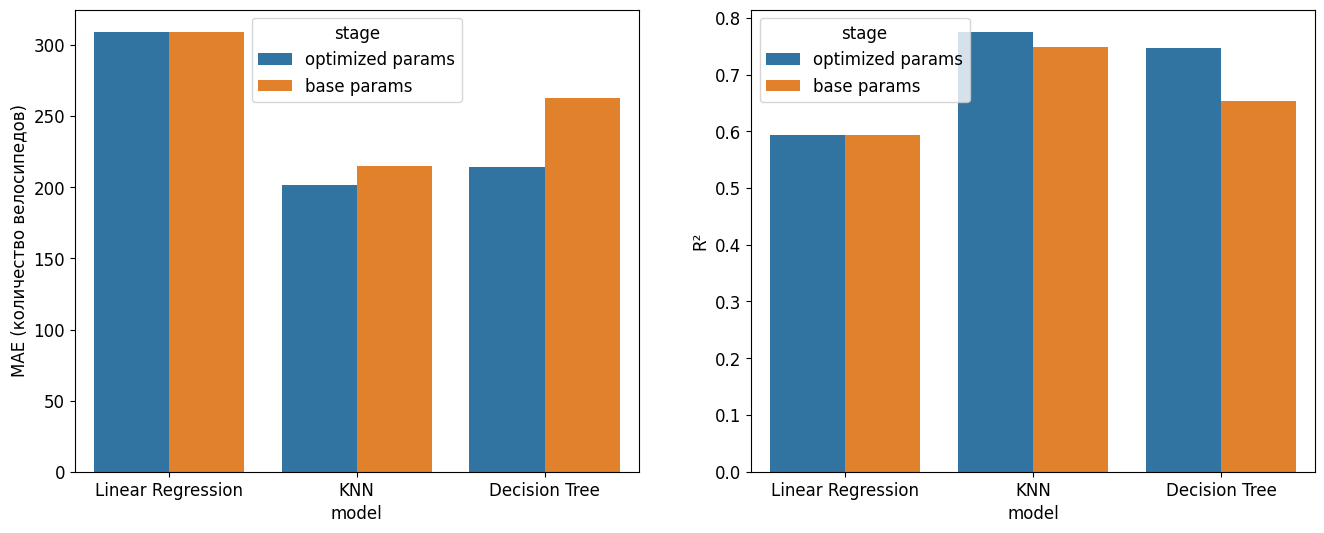

In [275]:
model_list = ['Linear Regression', 'KNN', 'Decision Tree']  
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=comparison, x='model', y='MAE', hue='stage', order=model_list, ax=axes[0])
axes[0].set_ylabel('MAE (количество велосипедов)')

sns.barplot(data=comparison, x='model', y='R2', hue='stage', order=model_list, ax=axes[1])
axes[1].set_ylabel('R²')

plt.show()

In [276]:
print(comparison)
print(comparison['model'].unique())

               model         MAE            MSE        RMSE        R2  \
0                KNN  201.801733   93797.771383  306.264218  0.775420   
1      Decision Tree  214.253980  105938.587453  325.482085  0.746352   
2                KNN  214.944007  105276.394361  324.463240  0.747937   
3      Decision Tree  262.849347  144691.981626  380.383992  0.653565   
4  Linear Regression  309.378458  170011.941291  412.325043  0.592941   
5  Linear Regression  309.378458  170011.941291  412.325043  0.592941   

              stage  
0  optimized params  
1  optimized params  
2       base params  
3       base params  
4  optimized params  
5       base params  
<StringArray>
['KNN', 'Decision Tree', 'Linear Regression']
Length: 3, dtype: str


<h3>Вывод</h3>

- После подбора гиперпараметров через Optuna обе нелинейные модели улучшили качество: MAE Decision Tree снизился с 263 до 214, а KNN с 215 до 202. Гиперпараметры были заданы неверно, особенно ограничение глубины дерева
 
- KNN с гиперпараметрами n_neighbors=6, weights='distance', p=1 показывает лучший результат среди всех моделей наименьший MAE (202)

- Decision Tree обгоняет линейную регрессию, но уступает KNN вероятно, KNN усредняет по локальной окрестности и точнее улавливает плавные переходы
- Линейная регрессия остаётся худшей моделью по всем метрикам.
- Финальная модель KNN с параметрами n_neighbors=6, weights='distance', p=1.

<h2>Этап 7. Финальная модель: обучение лучшей модели, сохранение готового пайплайна с помощью joblib</h2>

In [277]:
best_knn = KNeighborsRegressor(n_neighbors=6, weights='distance', p=1)

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_knn)
])

final_pipeline.fit(X_train, y_train)

y_test_pred = final_pipeline.predict(X_test)

mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Финальная модель KNN")
print(f"MAE:  {mae_test:.2f}")
print(f"MSE:  {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R2:   {r2_test:.4f}")

Финальная модель KNN
MAE:  200.99
MSE:  94702.07
RMSE: 307.74
R2:   0.7686


<h3>Сохранение артефактов для использования модели</h3>

In [278]:
def run(train, test, pipeline, group_col='Seasons', target_col='Rented Bike Count'):
    X_train = train.drop(columns=target_col)
    y_train = train[target_col]
    X_test = test.drop(columns=target_col)
    y_test = test[target_col]
    
    X_train, season_medians = fill_by_group_median(X_train, group_col=group_col, num_cols=num_cols)
    X_test, skip = fill_by_group_median(X_test, group_col=group_col, num_cols=num_cols, medians=season_medians)
    
    X_train = add_features(X_train)
    X_test = add_features(X_test)
    
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    metrics_train = compute_metrics(y_train, y_train_pred)
    metrics_test = compute_metrics(y_test, y_test_pred)
    
    return {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "y_train_pred": y_train_pred, "y_test_pred": y_test_pred,
        "metrics_train": metrics_train, "metrics_test": metrics_test,
        "season_medians": season_medians
    }

In [279]:
def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

In [280]:
result = run(train=train, test=test, pipeline=final_pipeline)
print("Метрики на test:", result['metrics_test'])

joblib.dump(final_pipeline, 'bike_demand_knn_pipeline.joblib')
joblib.dump(result['season_medians'], 'season_medians.joblib')
joblib.dump(run, 'run.joblib')
joblib.dump(add_features, 'add_features.joblib')
joblib.dump(fill_by_group_median, 'fill_by_group_median.joblib')
joblib.dump(compute_metrics, 'compute_metrics.joblib')

Метрики на test: {'MAE': 200.99117659235839, 'MSE': 94702.07346492822, 'RMSE': np.float64(307.73701997798094), 'R2': 0.7685755378117045}


['compute_metrics.joblib']

In [281]:
loaded_pipeline = joblib.load('bike_demand_knn_pipeline.joblib')
loaded_run = joblib.load('run.joblib')

result_check = loaded_run(train=train, test=test, pipeline=loaded_pipeline)
print("Метрики на test:", result_check['metrics_test'])

Метрики на test: {'MAE': 200.99117659235839, 'MSE': 94702.07346492822, 'RMSE': np.float64(307.73701997798094), 'R2': 0.7685755378117045}


<h2>Этап 8. Отчёт: описание полученных результатов, сравнение моделей и обоснование выбора лучшего решения</h2>

### Общий вывод по проекту
Цель:
Разработать модель машинного обучения для более точного прогнозирования почасового спроса на велосипеды, способную учитывать нелинейные зависимости между погодными условиями и активностью
### Что было сделано
1. Проведён EDA: обнаружен нелинейный характер зависимости спроса от температуры, влажности и солнечной радиации 
   найдена сезонность и суточная цикличность спроса.
2. Пропуски в числовых признаках заполнены медианой по сезону
3. Собран базовый пайплайн, на котором обучены Linear Regression, KNN, Decision Tree.
4. Добавлены три признака (ощущаемая температура, отклонение от  комфортной температуры, скорректированная радиация) дали 
   небольшой прирост качества
5. Гиперпараметры KNN и Decision Tree подобраны через Optuna 
6. Финальное сравнение проведено через кросс-валидацию на тренировочных данных

### Итоговые метрики (кросс-валидация)

| Модель             | MAE     | RMSE    | R²    |
|--------------------|---------|---------|-------|
| Linear Regression  | 309.4   | 412.3   | 0.593 |
| Decision Tree (опт) | 214.3  | 325.5   | 0.746 |
| KNN (опт)      | 201.8 | 306.3 | 0.775 |

### Метрики финальной модели на тестовой выборке (KNN, n_neighbors=6, weights='distance', p=1)
- MAE = 200.99
- RMSE = 307.74
- R² = 0.7686

### Почему KNN лучше
- Линейная регрессия показала худший результа. Она не способна улавливать нелинейные зависимости спроса от температуры, влажности и радиации, 
  обнаруженные на этапе EDA.
- Decision Tree обошла линейную модель (R² 0.75 > 0.59), но чуть менее точный результат, чем KNN из-за ступенчатых границ разбиения


### Бизнес-рекомендация
Новая модель снижает среднюю ошибку прогноза почасового спроса с 310 велосипедов до 201 велосипеда улучшение точности на 35%, новая модель позволит оптимизировать расходы на логистику тем самым уменьшив затраты

### Возможные дальнейшие шаги
- Добавить скользящие признаки, если данные хранятся по времени
- Добавить изменение спроса по отдельным частям города, чтобы модель не видела город как единую точку 